# Dual Si(Li) `22Na` Spectrum Analysis

Analyze the multithreaded Geant4 output table for the dual-sided Si(Li) positron spectrometer with three HPGe detectors.

This notebook expects the default Parquet file at `output/dual_sili_22na.parquet` and produces spectra, coincidence plots, symmetry checks, and peak/edge fits.

## Plan

- Load the event-by-event Parquet table and summarize nonzero detector rates.
- Plot Si(Li) single-detector and summed spectra, including symmetry comparisons.
- Plot HPGe individual and combined spectra.
- Fit the 511 keV and 1274.5 keV HPGe full-energy peaks with a Gaussian plus linear background.
- Estimate HPGe Compton edges with a smeared-step model.
- Plot Si(Li)-HPGe coincidence and gated spectra.
- Add a triple full-energy HPGe tag: two 511 keV annihilation photons plus the 1274.5 keV gamma.

All plots are Matplotlib figures. The helper `savefig` displays them inline in Jupyter and also writes PNG copies to `output/notebook_figures/`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import pandas as pd
import matplotlib
try:
    IN_NOTEBOOK = "IPKernelApp" in get_ipython().config
except Exception:
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import curve_fit
from scipy.special import erfc

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# Configuration
NOTEBOOK_PATH = Path.cwd()
REPO_ROOT = NOTEBOOK_PATH
if not (REPO_ROOT / "output").exists():
    # Common when running from analysis/notebooks in Jupyter.
    REPO_ROOT = NOTEBOOK_PATH.parents[1]

DATA_PATH = REPO_ROOT / "output" / "dual_sili_22na_50000000.parquet"
FIG_DIR = REPO_ROOT / "output" / "notebook_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_TIME_NS = 1.0e20 * 1.0e9
HPGE_COLUMNS = ["E_HPGe_1_keV", "E_HPGe_2_keV", "E_HPGe_3_keV"]
SILI_COLUMNS = ["E_SiLi_1_keV", "E_SiLi_2_keV"]

EXPECTED = {
    "annihilation_keV": 511.0,
    "na22_gamma_keV": 1274.5,
}
EXPECTED["compton_511_keV"] = EXPECTED["annihilation_keV"] * (1 - 1 / (1 + 2 * EXPECTED["annihilation_keV"] / 511.0))
EXPECTED["compton_1274_keV"] = EXPECTED["na22_gamma_keV"] * (1 - 1 / (1 + 2 * EXPECTED["na22_gamma_keV"] / 511.0))

print(f"Reading: {DATA_PATH}")
print(f"Figures: {FIG_DIR}")
print(EXPECTED)

Reading: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/dual_sili_22na_50000000.parquet
Figures: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures
{'annihilation_keV': 511.0, 'na22_gamma_keV': 1274.5, 'compton_511_keV': 340.6666666666667, 'compton_1274_keV': 1061.6668300653596}


## Load And Sanity Check

Each row is one simulated event. Energies are raw deposited energies in the active detector volumes; no electronic resolution smearing is applied.

In [3]:
df = pd.read_parquet(DATA_PATH)
print(f"rows={len(df):,}, columns={len(df.columns)}")
display(df.head())

event_summary = pd.DataFrame({
    "quantity": [
        "events",
        "events with nonzero Si(Li)",
        "events with nonzero HPGe",
        "events with both Si(Li) and HPGe",
    ],
    "count": [
        len(df),
        int((df["E_SiLi_sum_keV"] > 0).sum()),
        int((df[HPGE_COLUMNS].sum(axis=1) > 0).sum()),
        int(((df["E_SiLi_sum_keV"] > 0) & (df[HPGE_COLUMNS].sum(axis=1) > 0)).sum()),
    ],
})
event_summary["fraction"] = event_summary["count"] / len(df)
display(event_summary)

display(df[SILI_COLUMNS + ["E_SiLi_sum_keV"] + HPGE_COLUMNS].describe().T)

rows=100,000,000, columns=18


,eventID,E_SiLi_1_keV,E_SiLi_2_keV,E_SiLi_sum_keV,E_HPGe_1_keV,E_HPGe_2_keV,E_HPGe_3_keV,E_total_all_detectors_keV,Nhit_SiLi_1,Nhit_SiLi_2,Nhit_HPGe_1,Nhit_HPGe_2,Nhit_HPGe_3,tfirst_SiLi_1_ns,tfirst_SiLi_2_ns,tfirst_HPGe_1_ns,tfirst_HPGe_2_ns,tfirst_HPGe_3_ns
0,14142,184.634248,0.000000,184.634248,0.000000,0.0,0.000000,184.634248,21,0,0,0,0,1.000000e+29,-1.000000e+00,-1.000000e+00,-1.0,-1.000000e+00
1,14143,162.933673,0.000000,162.933673,0.000000,0.0,0.000000,162.933673,75,0,0,0,0,1.000000e+29,-1.000000e+00,-1.000000e+00,-1.0,-1.000000e+00
2,14144,254.709224,0.000000,254.709224,0.000000,0.0,279.568995,534.278219,22,0,0,0,22,1.000000e+29,-1.000000e+00,-1.000000e+00,-1.0,1.000000e+29
3,14145,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0,0,0,0,0,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.0,-1.000000e+00
4,14146,500.328804,37.704222,538.033026,259.400389,0.0,0.000000,797.433416,45,23,9,0,0,1.000000e+29,1.000000e+29,1.000000e+29,-1.0,-1.000000e+00


,quantity,count,fraction
0,events,100000000,1.000000
1,events with nonzero Si(Li),88290653,0.882907
2,events with nonzero HPGe,44251091,0.442511
3,events with both Si(Li) and HPGe,41353001,0.413530


,count,mean,std,min,25%,50%,75%,max
E_SiLi_1_keV,100000000.0,146.403885,214.613713,0.0,0.000000,55.370334,226.082237,2449.144765
E_SiLi_2_keV,100000000.0,146.403260,214.622322,0.0,0.000000,55.384975,226.068242,2281.412935
E_SiLi_sum_keV,100000000.0,292.807144,284.932736,0.0,93.181378,232.074658,393.571966,2459.209036
E_HPGe_1_keV,100000000.0,83.214743,231.792998,0.0,0.000000,0.000000,0.000000,2353.007292
E_HPGe_2_keV,100000000.0,83.226818,231.846708,0.0,0.000000,0.000000,0.000000,2503.705491
E_HPGe_3_keV,100000000.0,84.190421,232.273543,0.0,0.000000,0.000000,0.000000,2551.126673


In [4]:
def finite_positive(values, threshold=0.0):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values) & (values > threshold)]


def hist_counts(values, bins):
    counts, edges = np.histogram(values, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    return counts.astype(float), centers, widths


def step_hist(ax, values, bins, label=None, **kwargs):
    counts, edges = np.histogram(values, bins=bins)
    ax.stairs(counts, edges, label=label, **kwargs)
    return counts, edges


def savefig(fig, name):
    out = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(out, dpi=180)
    display(fig)
    if not IN_NOTEBOOK:
        plt.close(fig)
    print(f"saved {out.relative_to(REPO_ROOT)}")


def gaussian_linear(x, amp, mu, sigma, slope, intercept):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + slope * x + intercept


def smeared_edge(x, low, high, edge, sigma, slope):
    # high below the edge, low above the edge, with a linear local background.
    return low + 0.5 * (high - low) * erfc((x - edge) / (np.sqrt(2) * sigma)) + slope * (x - edge)


def fit_peak(values, expected, window=25.0, bin_width=1.0, label="peak"):
    values = finite_positive(values)
    lo, hi = expected - window, expected + window
    bins = np.arange(lo, hi + bin_width, bin_width)
    counts, centers, _ = hist_counts(values, bins)
    if counts.sum() < 10 or np.count_nonzero(counts) < 1:
        return {"label": label, "ok": False, "reason": "too few counts", "expected_keV": expected}

    # Keep zero-count side bins. They stabilize fits to very narrow unsmeared peaks.
    x = centers
    y = counts
    sigma_y = np.sqrt(np.maximum(y, 1.0))
    local_bg = np.percentile(y, 20)
    p0 = [max(y.max() - local_bg, 1.0), centers[np.argmax(y)], 0.6, 0.0, max(local_bg, 0.0)]
    bounds = ([0.0, lo, 0.03, -np.inf, -np.inf], [np.inf, hi, window, np.inf, np.inf])
    try:
        popt, pcov = curve_fit(
            gaussian_linear, x, y, p0=p0, sigma=sigma_y,
            absolute_sigma=True, bounds=bounds, maxfev=50000
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as exc:
        return {"label": label, "ok": False, "reason": str(exc), "expected_keV": expected}

    amp, mu, sigma, slope, intercept = popt
    fwhm = 2.354820045 * abs(sigma)
    area = amp * abs(sigma) * np.sqrt(2 * np.pi) / bin_width
    return {
        "label": label, "ok": True, "expected_keV": expected,
        "mu_keV": mu, "mu_err_keV": perr[1],
        "sigma_keV": abs(sigma), "sigma_err_keV": perr[2],
        "fwhm_keV": fwhm, "area_counts": area,
        "popt": popt, "pcov": pcov, "x": x, "y": y, "bins": bins,
    }


def fit_edge(values, expected, window=80.0, bin_width=2.0, label="edge"):
    values = finite_positive(values)
    lo, hi = expected - window, expected + window
    bins = np.arange(lo, hi + bin_width, bin_width)
    counts, centers, _ = hist_counts(values, bins)
    mask = counts > 0
    if mask.sum() < 10 or counts.sum() < 40:
        return {"label": label, "ok": False, "reason": "too few counts", "expected_keV": expected}

    x = centers[mask]
    y = counts[mask]
    sigma_y = np.sqrt(np.maximum(y, 1.0))
    left = y[x < expected]
    right = y[x > expected]
    p0 = [np.median(right) if len(right) else 1.0, np.median(left) if len(left) else y.max(), expected, 8.0, 0.0]
    bounds = ([-np.inf, -np.inf, lo, 0.5, -np.inf], [np.inf, np.inf, hi, window, np.inf])
    try:
        popt, pcov = curve_fit(
            smeared_edge, x, y, p0=p0, sigma=sigma_y,
            absolute_sigma=True, bounds=bounds, maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as exc:
        return {"label": label, "ok": False, "reason": str(exc), "expected_keV": expected}

    return {
        "label": label, "ok": True, "expected_keV": expected,
        "edge_keV": popt[2], "edge_err_keV": perr[2],
        "sigma_keV": abs(popt[3]), "popt": popt, "pcov": pcov,
        "x": x, "y": y, "bins": bins,
    }

## Si(Li) Spectra And Symmetry

The two Si(Li) detectors should agree statistically. The summed spectrum is the quantity most useful for recovering split-energy/backscatter events.

In [ ]:
sili1 = df["E_SiLi_1_keV"].to_numpy()
sili2 = df["E_SiLi_2_keV"].to_numpy()
silisum = df["E_SiLi_sum_keV"].to_numpy()

bins_sili = np.linspace(0, 1800, 361)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
step_hist(axes[0], finite_positive(sili1), bins_sili, label="SiLi_1", linewidth=1.4)
step_hist(axes[0], finite_positive(sili2), bins_sili, label="SiLi_2", linewidth=1.4)
step_hist(axes[0], finite_positive(silisum), bins_sili, label="SiLi sum", linewidth=1.4)
axes[0].set_xlabel("Energy deposit [keV]")
axes[0].set_ylabel("Events / 5 keV")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Si(Li) active energy deposits")

c1, edges = np.histogram(finite_positive(sili1), bins=bins_sili)
c2, _ = np.histogram(finite_positive(sili2), bins=bins_sili)
centers = 0.5 * (edges[:-1] + edges[1:])
ratio = np.divide(c1, c2, out=np.full_like(c1, np.nan, dtype=float), where=c2 > 0)
axes[1].axhline(1.0, color="0.25", linewidth=1)
axes[1].plot(centers, ratio, drawstyle="steps-mid", linewidth=1.2)
axes[1].set_ylim(0, 2.5)
axes[1].set_xlabel("Energy deposit [keV]")
axes[1].set_ylabel("SiLi_1 / SiLi_2 counts")
axes[1].set_title("Symmetry ratio")
savefig(fig, "sili_spectra_symmetry.png")

In [ ]:
# Quantify symmetry with simple per-event and binned metrics.
nonzero_either = (sili1 > 0) | (sili2 > 0)
symmetry_metrics = {
    "mean_E_SiLi_1_keV": float(np.mean(sili1)),
    "mean_E_SiLi_2_keV": float(np.mean(sili2)),
    "mean_difference_keV": float(np.mean(sili1 - sili2)),
    "median_abs_difference_when_hit_keV": float(np.median(np.abs(sili1[nonzero_either] - sili2[nonzero_either]))),
    "events_split_between_both_SiLi": int(((sili1 > 0) & (sili2 > 0)).sum()),
    "events_only_SiLi_1": int(((sili1 > 0) & (sili2 <= 0)).sum()),
    "events_only_SiLi_2": int(((sili2 > 0) & (sili1 <= 0)).sum()),
}
display(pd.Series(symmetry_metrics, name="value").to_frame())

## Si(Li) Energy Sharing

This 2D view highlights events where positron energy is split between both detectors. Diagonal structure corresponds to approximately conserved summed deposited energy.

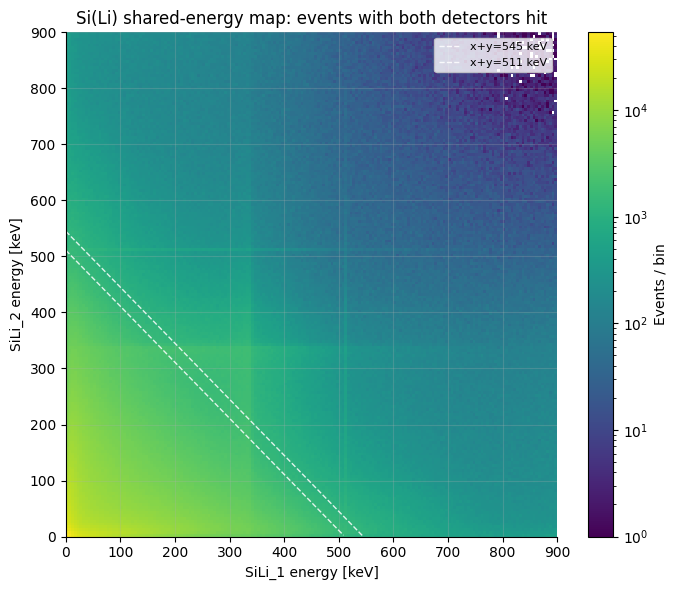

saved output/notebook_figures/sili_energy_sharing_2d.png


,events
events with SiLi_1 > 0.1 keV,62829946
events with SiLi_2 > 0.1 keV,62824577
events with both Si(Li) detectors > 0.1 keV,37396895


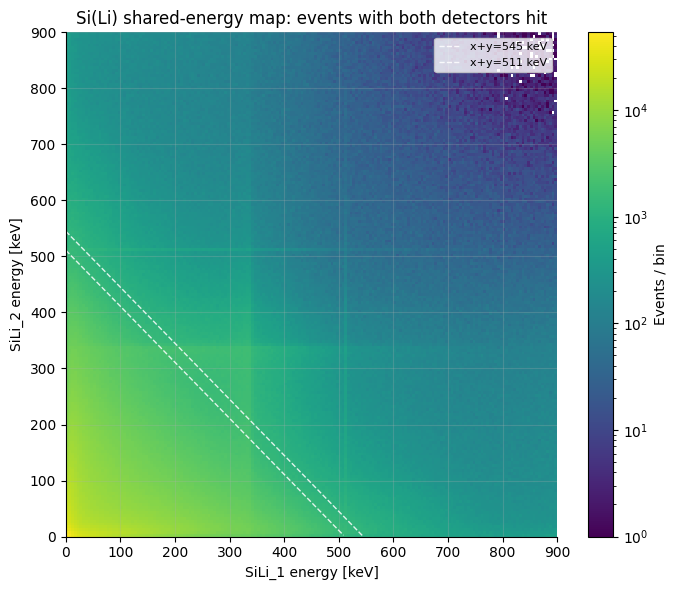

In [24]:
from matplotlib.colors import LogNorm

split_mask = (
    np.isfinite(sili1)
    & np.isfinite(sili2)
    & (sili1 > 0.1)
    & (sili2 > 0.1)
)

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(
    sili1[split_mask],
    sili2[split_mask],
    bins=180,
    range=[[0, 900], [0, 900]],
    cmap="viridis",
    norm=LogNorm(),
    cmin=1,
)
fig.colorbar(h[3], ax=ax, label="Events / bin")

x = np.linspace(0, 900, 300)
for total, label in [(545.0, "x+y=545 keV"), (EXPECTED["annihilation_keV"], "x+y=511 keV")]:
    y = total - x
    visible = (y >= 0) & (y <= 900)
    ax.plot(x[visible], y[visible], color="white", linewidth=1.0, linestyle="--", alpha=0.85, label=label)

ax.set_xlabel("SiLi_1 energy [keV]")
ax.set_ylabel("SiLi_2 energy [keV]")
ax.set_title("Si(Li) shared-energy map: events with both detectors hit")
ax.legend(fontsize=8, loc="upper right")
savefig(fig, "sili_energy_sharing_2d.png")

split_counts = pd.Series({
    "events with SiLi_1 > 0.1 keV": int((sili1 > 0.1).sum()),
    "events with SiLi_2 > 0.1 keV": int((sili2 > 0.1).sum()),
    "events with both Si(Li) detectors > 0.1 keV": int(split_mask.sum()),
})
display(split_counts.to_frame("events"))

## HPGe Spectra

The individual HPGe spectra test the `+X`, `-X`, and `+Y` detector response. The combined spectrum gives higher statistics for fitting the 511 keV annihilation line and the 1274.5 keV gamma.

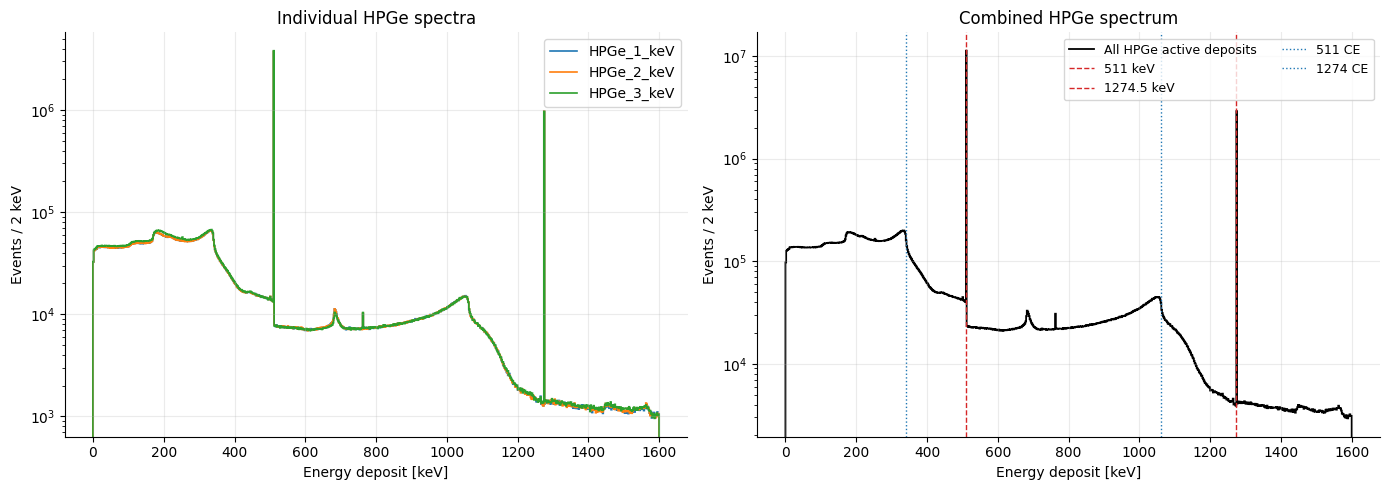

saved output/notebook_figures/hpge_spectra.png


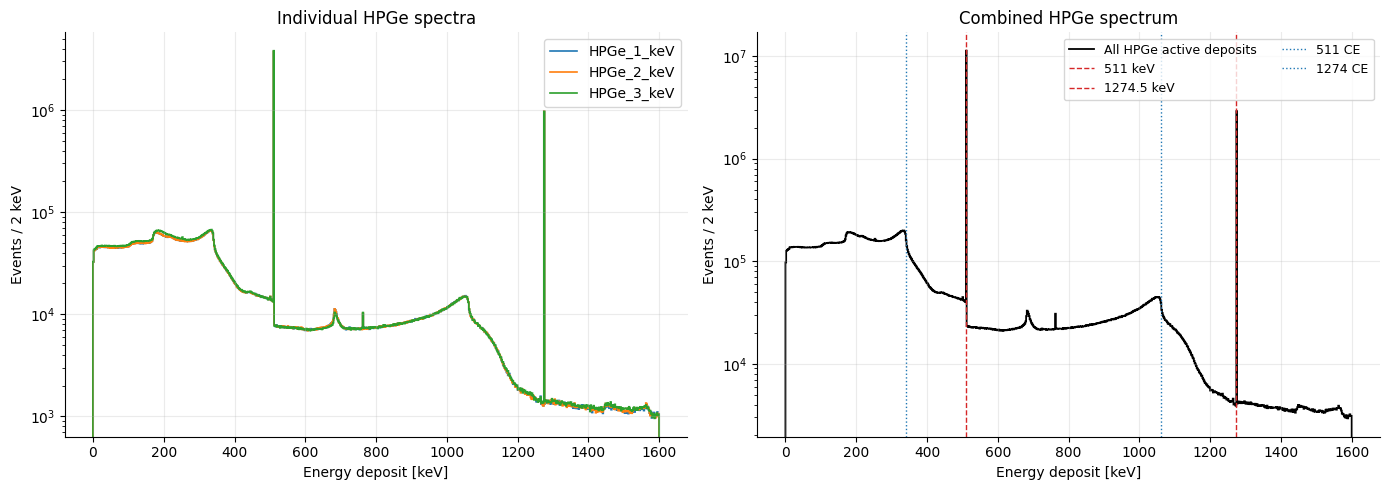

In [25]:
hpge = {name: df[name].to_numpy() for name in HPGE_COLUMNS}
hpge_all = np.concatenate([finite_positive(v, threshold=0.1) for v in hpge.values()])

bins_hpge = np.linspace(0, 1600, 801)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, values in hpge.items():
    step_hist(axes[0], finite_positive(values, threshold=0.1), bins_hpge, label=col.replace("E_", ""), linewidth=1.2)
axes[0].set_xlabel("Energy deposit [keV]")
axes[0].set_ylabel("Events / 2 keV")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Individual HPGe spectra")

step_hist(axes[1], hpge_all, bins_hpge, label="All HPGe active deposits", color="black", linewidth=1.3)
for energy, label in [(EXPECTED["annihilation_keV"], "511"), (EXPECTED["na22_gamma_keV"], "1274.5")]:
    axes[1].axvline(energy, color="tab:red", linestyle="--", linewidth=1, label=f"{label} keV")
for energy, label in [(EXPECTED["compton_511_keV"], "511 CE"), (EXPECTED["compton_1274_keV"], "1274 CE")]:
    axes[1].axvline(energy, color="tab:blue", linestyle=":", linewidth=1, label=label)
axes[1].set_xlabel("Energy deposit [keV]")
axes[1].set_ylabel("Events / 2 keV")
axes[1].set_yscale("log")
axes[1].legend(ncol=2, fontsize=9)
axes[1].set_title("Combined HPGe spectrum")
savefig(fig, "hpge_spectra.png")

## HPGe Full-Energy Peak Fits

Fits use a Gaussian peak plus linear background in a narrow window. With unsmeared Geant4 energy deposits, the fitted width is mostly numerical/physical broadening from the event sample rather than electronics resolution. Very narrow single-bin peaks can also make covariance uncertainties ill-conditioned; use the centroids and areas as diagnostics, not calibrated detector-resolution estimates.

In [26]:
peak_fits = []
for label, values in [("HPGe_all", hpge_all)] + [(col.replace("E_", ""), finite_positive(vals, 0.1)) for col, vals in hpge.items()]:
    peak_fits.append(fit_peak(values, EXPECTED["annihilation_keV"], window=18, bin_width=1, label=f"{label} 511"))
    peak_fits.append(fit_peak(values, EXPECTED["na22_gamma_keV"], window=30, bin_width=1, label=f"{label} 1274.5"))

fit_table = pd.DataFrame([
    {k: v for k, v in fit.items() if k not in {"popt", "pcov", "x", "y", "bins"}}
    for fit in peak_fits
])
display(fit_table)

,label,ok,expected_keV,mu_keV,mu_err_keV,sigma_keV,sigma_err_keV,fwhm_keV,area_counts
0,HPGe_all 511,True,511.0,510.514221,0.001324,0.259197,0.000358,0.610363,5.334334e+06
1,HPGe_all 1274.5,True,1274.5,1274.003155,0.005632,0.235427,0.001353,0.554389,1.476119e+06
2,HPGe_1_keV 511,True,511.0,510.497204,0.002139,0.258809,0.000571,0.609448,1.779689e+06
3,HPGe_1_keV 1274.5,True,1274.5,1274.000388,0.009588,0.235756,0.002305,0.555164,4.875998e+05
4,HPGe_2_keV 511,True,511.0,510.497270,0.002142,0.258748,0.000572,0.609305,1.777857e+06
5,HPGe_2_keV 1274.5,True,1274.5,1274.005798,0.009410,0.236165,0.002269,0.556126,4.907089e+05
6,HPGe_3_keV 511,True,511.0,510.496336,0.002072,0.259159,0.000554,0.610273,1.806037e+06
7,HPGe_3_keV 1274.5,True,1274.5,1274.002207,0.009939,0.235308,0.002386,0.554108,4.854149e+05


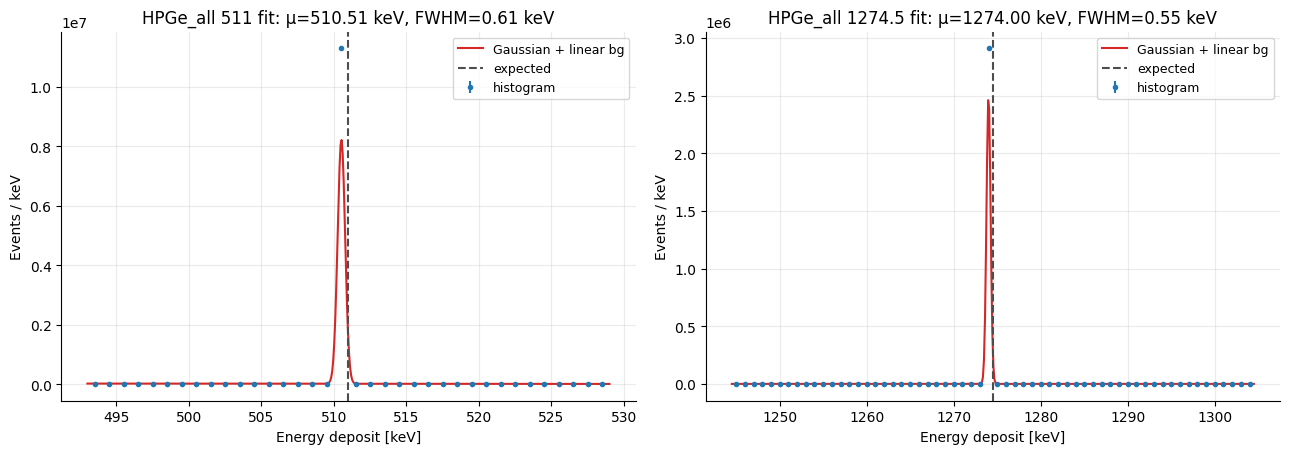

saved output/notebook_figures/hpge_full_energy_peak_fits.png


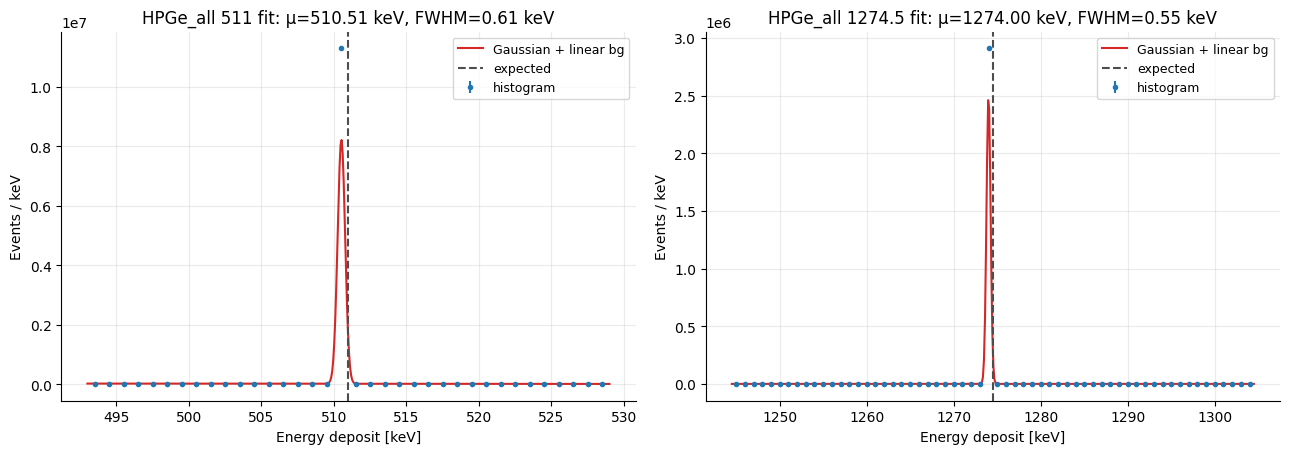

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, fit in zip(axes, [peak_fits[0], peak_fits[1]]):
    if not fit["ok"]:
        ax.text(0.05, 0.8, f"Fit failed: {fit['reason']}", transform=ax.transAxes)
        continue
    counts, edges = np.histogram(hpge_all, bins=fit["bins"])
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.errorbar(centers, counts, yerr=np.sqrt(np.maximum(counts, 1)), fmt="o", ms=3, label="histogram")
    xfine = np.linspace(edges[0], edges[-1], 500)
    ax.plot(xfine, gaussian_linear(xfine, *fit["popt"]), color="tab:red", label="Gaussian + linear bg")
    ax.axvline(fit["expected_keV"], color="0.3", linestyle="--", label="expected")
    ax.set_xlabel("Energy deposit [keV]")
    ax.set_ylabel("Events / keV")
    ax.set_title(f"{fit['label']} fit: μ={fit['mu_keV']:.2f} keV, FWHM={fit['fwhm_keV']:.2f} keV")
    ax.legend(fontsize=9)
savefig(fig, "hpge_full_energy_peak_fits.png")

## HPGe Compton Edge Estimates

The expected Compton edges are about 340.7 keV for 511 keV photons and 1061.7 keV for 1274.5 keV photons. The fit is a local smeared step, so treat it as a diagnostic estimate rather than a precision calibration.

,label,ok,expected_keV,edge_keV,edge_err_keV,sigma_keV
0,511 keV Compton edge,True,340.666667,355.069118,0.038608,24.657964
1,1274.5 keV Compton edge,True,1061.666830,1096.363573,0.119476,59.499832


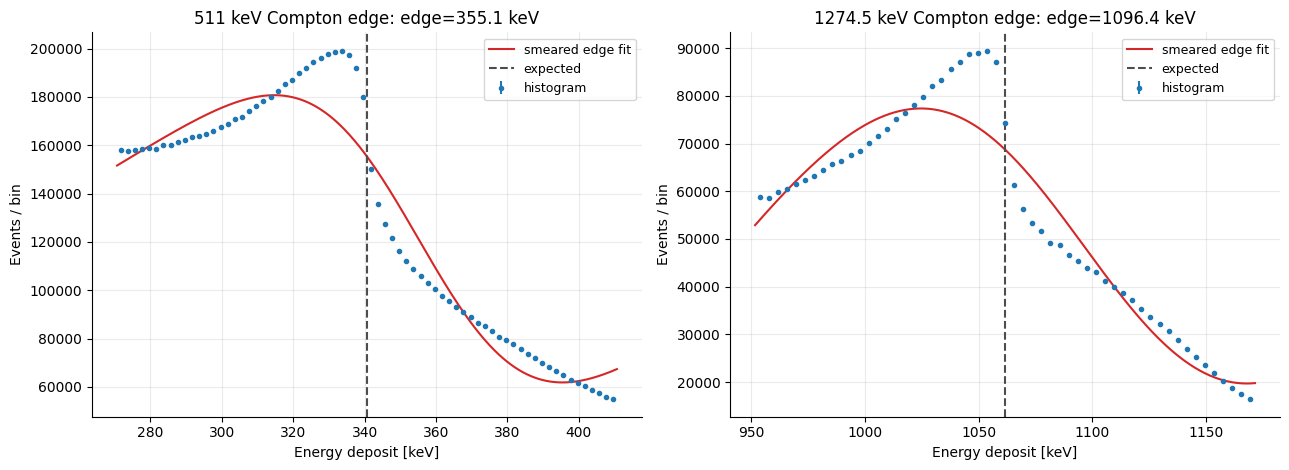

saved output/notebook_figures/hpge_compton_edge_fits.png


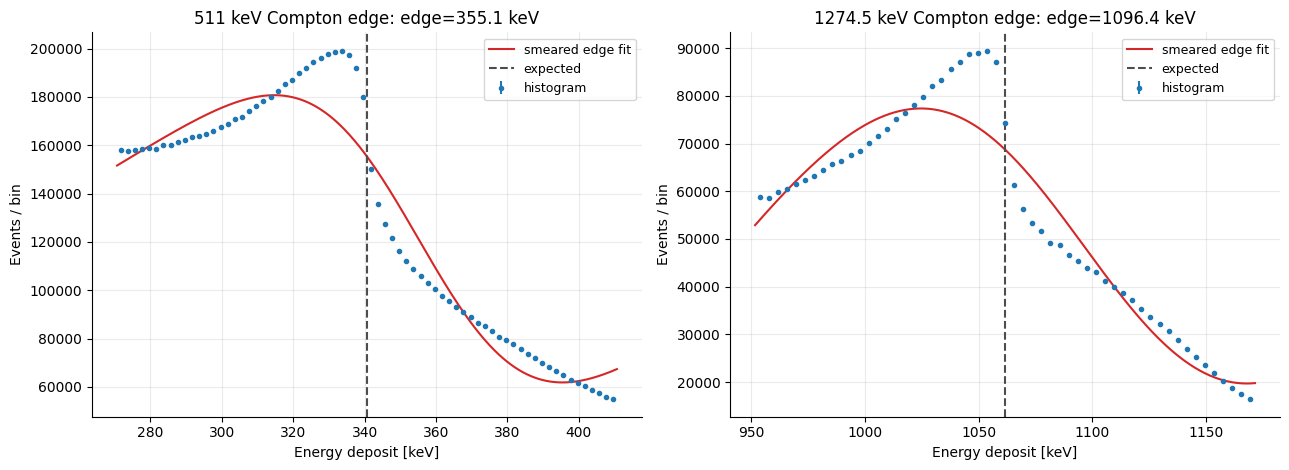

In [28]:
edge_fits = [
    fit_edge(hpge_all, EXPECTED["compton_511_keV"], window=70, bin_width=2, label="511 keV Compton edge"),
    fit_edge(hpge_all, EXPECTED["compton_1274_keV"], window=110, bin_width=4, label="1274.5 keV Compton edge"),
]
edge_table = pd.DataFrame([
    {k: v for k, v in fit.items() if k not in {"popt", "pcov", "x", "y", "bins"}}
    for fit in edge_fits
])
display(edge_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, fit in zip(axes, edge_fits):
    if not fit["ok"]:
        ax.text(0.05, 0.8, f"Fit failed: {fit['reason']}", transform=ax.transAxes)
        continue
    counts, edges = np.histogram(hpge_all, bins=fit["bins"])
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.errorbar(centers, counts, yerr=np.sqrt(np.maximum(counts, 1)), fmt="o", ms=3, label="histogram")
    xfine = np.linspace(edges[0], edges[-1], 500)
    ax.plot(xfine, smeared_edge(xfine, *fit["popt"]), color="tab:red", label="smeared edge fit")
    ax.axvline(fit["expected_keV"], color="0.3", linestyle="--", label="expected")
    ax.set_xlabel("Energy deposit [keV]")
    ax.set_ylabel("Events / bin")
    ax.set_title(f"{fit['label']}: edge={fit.get('edge_keV', np.nan):.1f} keV")
    ax.legend(fontsize=9)
savefig(fig, "hpge_compton_edge_fits.png")

## Si(Li) Sum Tail / Endpoint Diagnostic

The `22Na` beta-plus endpoint for the branch feeding the 1274.5 keV state is about 545 keV. In this geometry the Si(Li) sum includes backscatter, annihilation photon deposits, and gamma interactions, so this simple linear tail intercept is only a qualitative diagnostic.

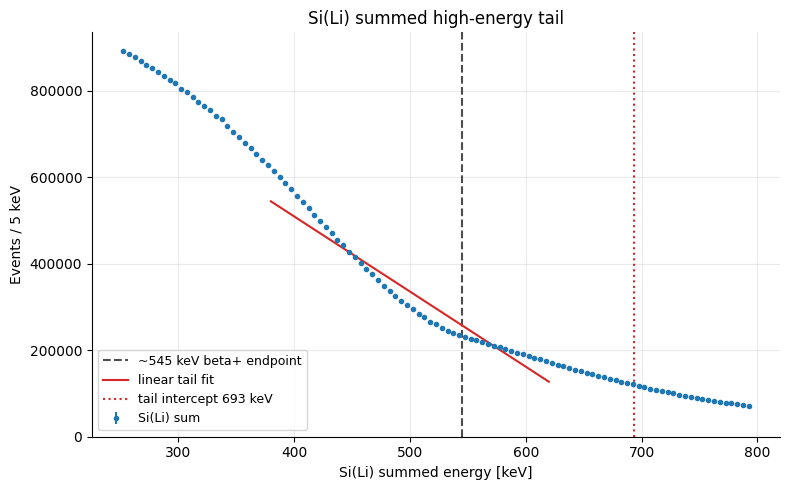

saved output/notebook_figures/sili_sum_tail_endpoint.png


,value
slope,-1.739118e+03
intercept,1.205465e+06
endpoint_keV,6.931471e+02


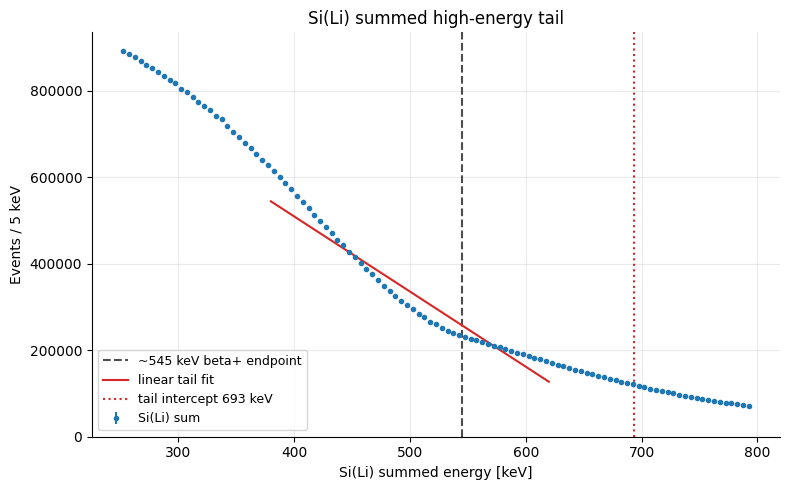

In [29]:
def rough_tail_endpoint(values, fit_range=(380, 620), bin_width=5):
    values = finite_positive(values)
    bins = np.arange(fit_range[0], fit_range[1] + bin_width, bin_width)
    counts, centers, _ = hist_counts(values, bins)
    mask = counts > 0
    if mask.sum() < 5:
        return None
    x = centers[mask]
    y = counts[mask]
    sigma = np.sqrt(np.maximum(y, 1))
    coeff, cov = np.polyfit(x, y, deg=1, w=1 / sigma, cov=True)
    slope, intercept = coeff
    endpoint = -intercept / slope if slope != 0 else np.nan
    return {"slope": slope, "intercept": intercept, "endpoint_keV": endpoint, "x": x, "y": y, "bins": bins, "cov": cov}

endpoint_fit = rough_tail_endpoint(silisum)
fig, ax = plt.subplots(figsize=(8, 5))
zoom_bins = np.arange(250, 800, 5)
counts, edges = np.histogram(finite_positive(silisum), bins=zoom_bins)
centers = 0.5 * (edges[:-1] + edges[1:])
ax.errorbar(centers, counts, yerr=np.sqrt(np.maximum(counts, 1)), fmt="o", ms=3, label="Si(Li) sum")
ax.axvline(545, color="0.3", linestyle="--", label="~545 keV beta+ endpoint")
if endpoint_fit:
    xfit = np.linspace(endpoint_fit["bins"][0], endpoint_fit["bins"][-1], 200)
    ax.plot(xfit, endpoint_fit["slope"] * xfit + endpoint_fit["intercept"], color="tab:red", label="linear tail fit")
    ax.axvline(endpoint_fit["endpoint_keV"], color="tab:red", linestyle=":", label=f"tail intercept {endpoint_fit['endpoint_keV']:.0f} keV")
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel("Events / 5 keV")
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.set_title("Si(Li) summed high-energy tail")
savefig(fig, "sili_sum_tail_endpoint.png")

if endpoint_fit:
    display(pd.Series({k: v for k, v in endpoint_fit.items() if k not in {"x", "y", "bins", "cov"}}, name="value").to_frame())

## Coincidence And Gated Spectra

These gates are deliberately simple and use raw deposited energy. Tight HPGe gates are possible because no detector resolution smearing is applied.

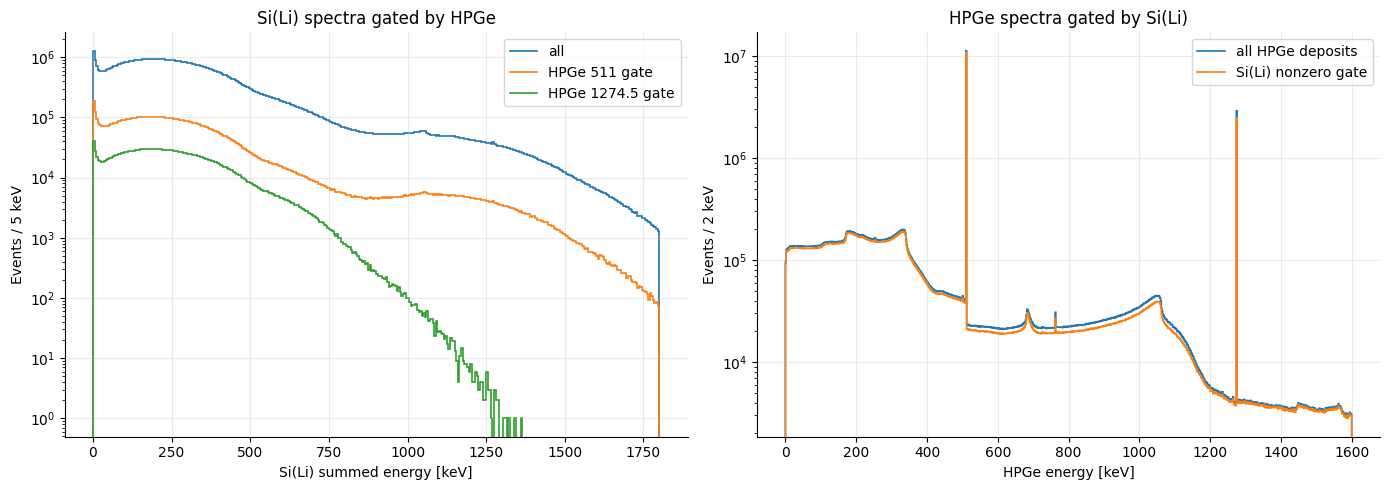

saved output/notebook_figures/coincidence_gated_spectra.png


,events
HPGe max in 511 gate,9669035
HPGe max in 1274.5 gate,2931775
Si(Li) hit and HPGe 511 gate,9258850
Si(Li) hit and HPGe 1274.5 gate,2505933


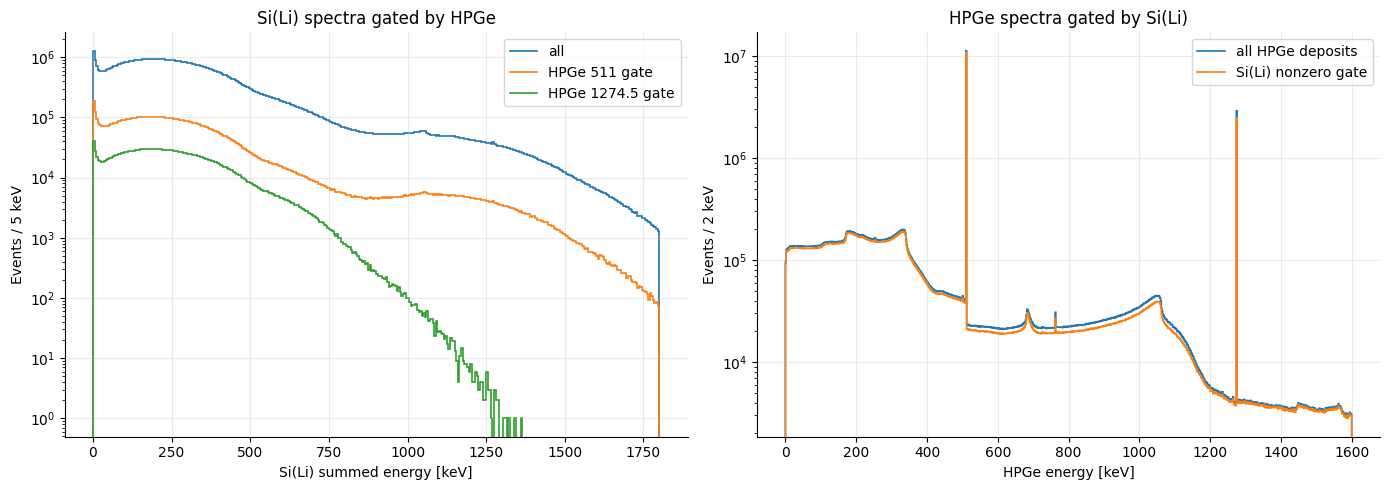

In [30]:
hpge_sum = df[HPGE_COLUMNS].sum(axis=1).to_numpy()
hpge_max = df[HPGE_COLUMNS].max(axis=1).to_numpy()

hpge_511_gate = (hpge_max > 508) & (hpge_max < 514)
hpge_1274_gate = (hpge_max > 1268) & (hpge_max < 1281)
sili_hit_gate = df["E_SiLi_sum_keV"].to_numpy() > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
step_hist(axes[0], finite_positive(silisum), bins_sili, label="all", linewidth=1.2)
step_hist(axes[0], finite_positive(silisum[hpge_511_gate]), bins_sili, label="HPGe 511 gate", linewidth=1.2)
step_hist(axes[0], finite_positive(silisum[hpge_1274_gate]), bins_sili, label="HPGe 1274.5 gate", linewidth=1.2)
axes[0].set_xlabel("Si(Li) summed energy [keV]")
axes[0].set_ylabel("Events / 5 keV")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Si(Li) spectra gated by HPGe")

step_hist(axes[1], hpge_all, bins_hpge, label="all HPGe deposits", linewidth=1.2)
step_hist(axes[1], finite_positive(df.loc[sili_hit_gate, HPGE_COLUMNS].to_numpy().ravel(), 0.1), bins_hpge, label="Si(Li) nonzero gate", linewidth=1.2)
axes[1].set_xlabel("HPGe energy [keV]")
axes[1].set_ylabel("Events / 2 keV")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("HPGe spectra gated by Si(Li)")
savefig(fig, "coincidence_gated_spectra.png")

coincidence_counts = pd.Series({
    "HPGe max in 511 gate": int(hpge_511_gate.sum()),
    "HPGe max in 1274.5 gate": int(hpge_1274_gate.sum()),
    "Si(Li) hit and HPGe 511 gate": int((sili_hit_gate & hpge_511_gate).sum()),
    "Si(Li) hit and HPGe 1274.5 gate": int((sili_hit_gate & hpge_1274_gate).sum()),
})
display(coincidence_counts.to_frame("events"))

## Back-To-Back 511 keV HPGe Gate

Require the two collinear HPGe detectors (`HPGe_1` on +X and `HPGe_2` on -X) to both be in the 511 keV full-energy window. `HPGe_3` is deliberately ignored here, so the 1274.5 keV gamma is not required.

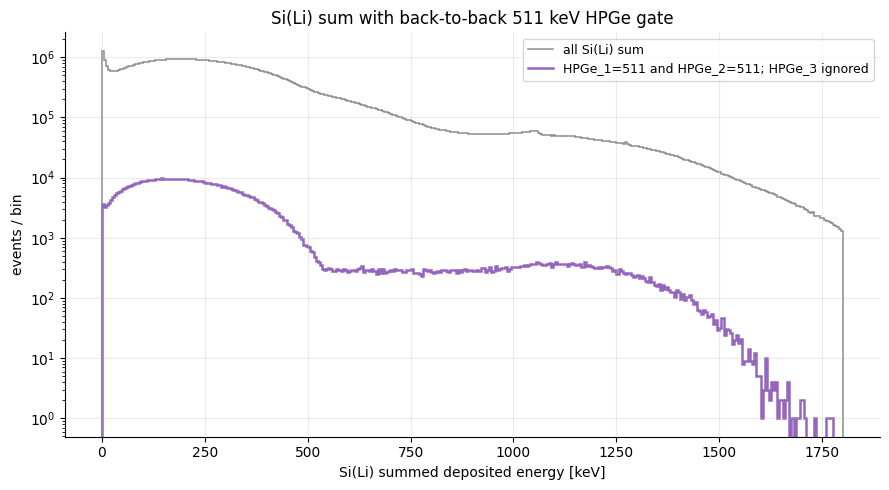

saved output/notebook_figures/sili_sum_back_to_back_511_hpge_gate.png


,events
"HPGe_1 511 + HPGe_2 511, HPGe_3 ignored",686760
same gate with nonzero Si(Li) sum,674521
same gate that also has HPGe_3 in 1274.5 keV window,8844
same gate without HPGe_3 in 1274.5 keV window,677916


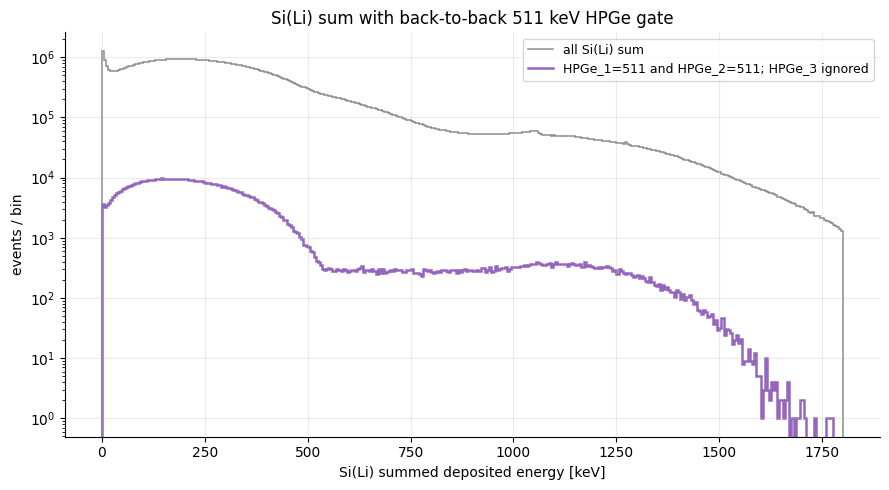

In [31]:
# Back-to-back 511 keV gate: require only the two opposing HPGe detectors.
# No condition is applied to HPGe_3, so the 1274.5 keV gamma is ignored.
E_H1 = df["E_HPGe_1_keV"].to_numpy()
E_H2 = df["E_HPGe_2_keV"].to_numpy()
E_H3 = df["E_HPGe_3_keV"].to_numpy()

WINDOW_511 = (508.0, 514.0)
WINDOW_1274 = (1268.0, 1281.0)

def in_window(values, window):
    lo, hi = window
    return (values >= lo) & (values <= hi)

h1_511 = in_window(E_H1, WINDOW_511)
h2_511 = in_window(E_H2, WINDOW_511)
h3_1274 = in_window(E_H3, WINDOW_1274)
back_to_back_511_gate = h1_511 & h2_511

fig, ax = plt.subplots(figsize=(9, 5))
step_hist(
    ax,
    finite_positive(silisum),
    bins_sili,
    label="all Si(Li) sum",
    linewidth=1.1,
    color="0.55",
)
step_hist(
    ax,
    finite_positive(silisum[back_to_back_511_gate]),
    bins_sili,
    label="HPGe_1=511 and HPGe_2=511; HPGe_3 ignored",
    linewidth=1.8,
    color="tab:purple",
)
ax.set_xlabel("Si(Li) summed deposited energy [keV]")
ax.set_ylabel("events / bin")
ax.set_yscale("log")
ax.set_title("Si(Li) sum with back-to-back 511 keV HPGe gate")
ax.legend(fontsize=9)
savefig(fig, "sili_sum_back_to_back_511_hpge_gate.png")

back_to_back_counts = pd.Series({
    "HPGe_1 511 + HPGe_2 511, HPGe_3 ignored": int(back_to_back_511_gate.sum()),
    "same gate with nonzero Si(Li) sum": int((back_to_back_511_gate & (silisum > 0)).sum()),
    "same gate that also has HPGe_3 in 1274.5 keV window": int((back_to_back_511_gate & h3_1274).sum()),
    "same gate without HPGe_3 in 1274.5 keV window": int((back_to_back_511_gate & ~h3_1274).sum()),
})
display(back_to_back_counts.to_frame("events"))

## Triple Full-Energy HPGe Tag

Require two HPGe detectors to be in the 511 keV full-energy peak and the remaining detector to be in the 1274.5 keV full-energy peak. This selects events where all three photons are fully tagged, strongly suppressing Compton-tag contamination in the selected Si(Li) summed spectrum.

Two gates are shown:

- **Strict topology:** `HPGe_1` and `HPGe_2` at 511 keV, `HPGe_3` at 1274.5 keV.
- **Any assignment:** any two HPGe detectors at 511 keV and the third at 1274.5 keV.

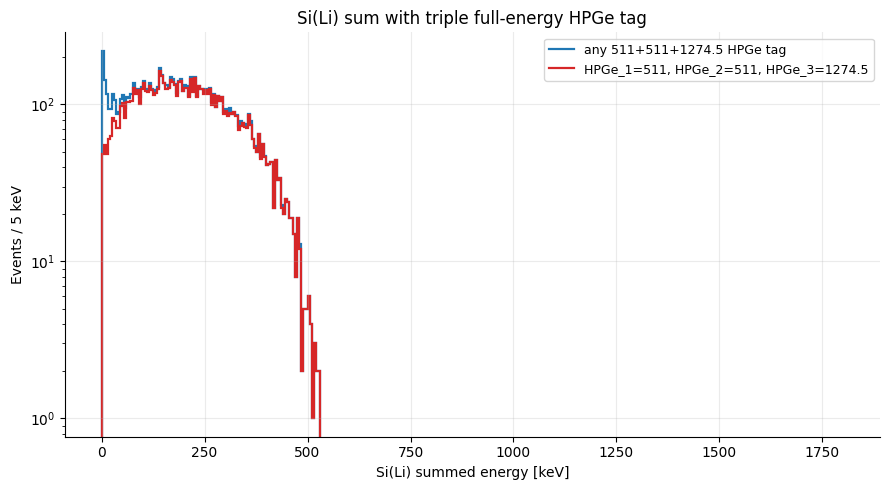

saved output/notebook_figures/sili_sum_triple_hpge_full_energy_tag.png


,events
strict HPGe_1 511 + HPGe_2 511 + HPGe_3 1274.5,8844
any two HPGe 511 + remaining HPGe 1274.5,9885
strict gate with nonzero Si(Li) sum,8646
any-assignment gate with nonzero Si(Li) sum,9399


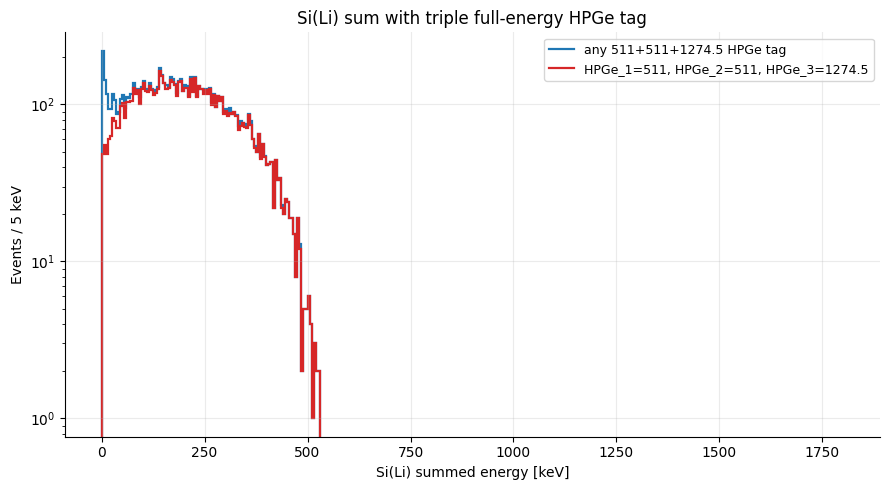

In [32]:
# Triple full-energy HPGe tag: two 511 keV photons plus the 1274.5 keV gamma.
# The windows are intentionally tight because the simulation output is unsmeared.
E_H1 = df["E_HPGe_1_keV"].to_numpy()
E_H2 = df["E_HPGe_2_keV"].to_numpy()
E_H3 = df["E_HPGe_3_keV"].to_numpy()

WINDOW_511 = (508.0, 514.0)
WINDOW_1274 = (1268.0, 1281.0)

def in_window(values, window):
    lo, hi = window
    return (values >= lo) & (values <= hi)

h1_511 = in_window(E_H1, WINDOW_511)
h2_511 = in_window(E_H2, WINDOW_511)
h3_511 = in_window(E_H3, WINDOW_511)
h1_1274 = in_window(E_H1, WINDOW_1274)
h2_1274 = in_window(E_H2, WINDOW_1274)
h3_1274 = in_window(E_H3, WINDOW_1274)


strict_511_511_1274_gate = h1_511 & h2_511 & h3_1274
any_511_511_1274_gate = (
    (h1_511 & h2_511 & h3_1274) |
    (h1_511 & h3_511 & h2_1274) |
    (h2_511 & h3_511 & h1_1274)
)

fig, ax = plt.subplots(figsize=(9, 5))
#step_hist(ax, finite_positive(silisum), bins_sili, label="all Si(Li) sum", linewidth=1.1, color="0.55")
step_hist(
    ax,
    finite_positive(silisum[any_511_511_1274_gate]),
    bins_sili,
    label="any 511+511+1274.5 HPGe tag",
    linewidth=1.6,
    color="tab:blue",
)
step_hist(
    ax,
    finite_positive(silisum[strict_511_511_1274_gate]),
    bins_sili,
    label="HPGe_1=511, HPGe_2=511, HPGe_3=1274.5",
    linewidth=1.6,
    color="tab:red",
)
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel("Events / 5 keV")
ax.set_yscale("log")
ax.legend(fontsize=9)
ax.set_title("Si(Li) sum with triple full-energy HPGe tag")
savefig(fig, "sili_sum_triple_hpge_full_energy_tag.png")

triple_gate_summary = pd.Series({
    "strict HPGe_1 511 + HPGe_2 511 + HPGe_3 1274.5": int(strict_511_511_1274_gate.sum()),
    "any two HPGe 511 + remaining HPGe 1274.5": int(any_511_511_1274_gate.sum()),
    "strict gate with nonzero Si(Li) sum": int((strict_511_511_1274_gate & (silisum > 0)).sum()),
    "any-assignment gate with nonzero Si(Li) sum": int((any_511_511_1274_gate & (silisum > 0)).sum()),
})
display(triple_gate_summary.to_frame("events"))

if any_511_511_1274_gate.sum() == 0:
    print("No triple full-energy-tagged events in this sample. This is expected for small runs; use the 50M-event production file for this gate.")

## Triple-Gated 22Na Beta-Plus Spectrum Fit

Fit the summed Si(Li) spectrum under the triple full-energy HPGe tag to a simple allowed beta-plus phase-space shape. This fit is intended as a spectrum-shape diagnostic; it does not include a Fermi function, detector response convolution, or detailed Si(Li) acceptance correction.

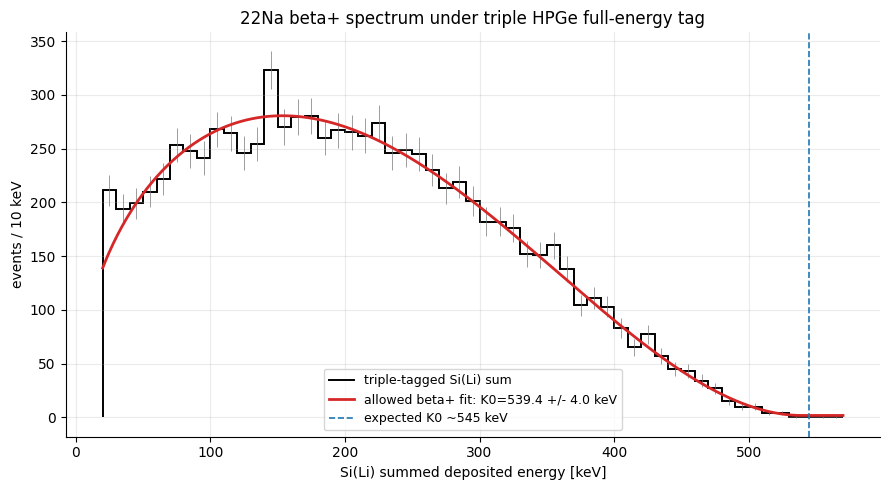

saved output/notebook_figures/sili_sum_triple_hpge_22na_beta_fit.png


,value
endpoint_keV,539.364823
endpoint_err_keV,3.976511
background_counts_per_bin,1.682780
chi2_ndof,1.015962
n_events_in_fit_range,8826.000000


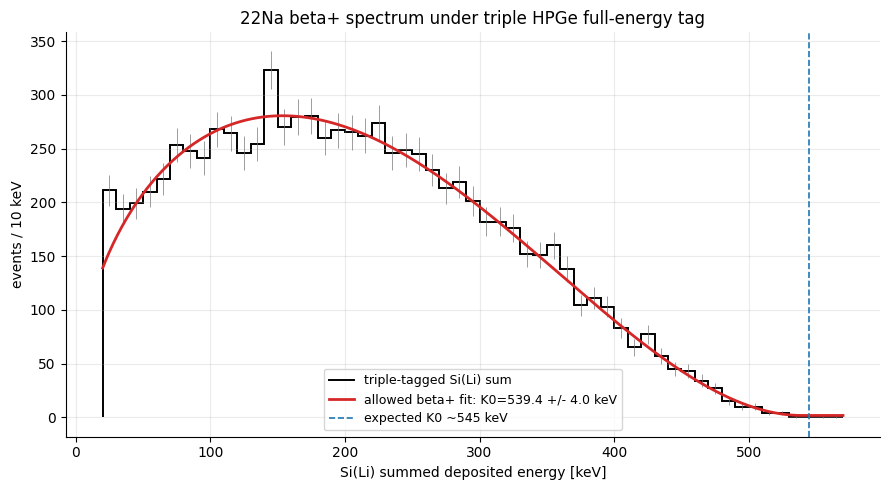

In [33]:
# 22Na beta-plus endpoint fit under the triple full-energy HPGe tag.
# Model: allowed beta+ phase space dN/dK proportional to p * W * (K0 - K)^2.
BETA_PLUS_ENDPOINT_22NA_KEV = 545.0
ELECTRON_MASS_KEV = 510.99895


def beta_plus_allowed_shape(kinetic_keV, endpoint_keV):
    kinetic_keV = np.asarray(kinetic_keV, dtype=float)
    shape = np.zeros_like(kinetic_keV, dtype=float)
    mask = (kinetic_keV > 0.0) & (kinetic_keV < endpoint_keV)
    if not np.any(mask):
        return shape
    k = kinetic_keV[mask]
    momentum_keV = np.sqrt(k * (k + 2.0 * ELECTRON_MASS_KEV))
    total_energy_keV = k + ELECTRON_MASS_KEV
    shape[mask] = momentum_keV * total_energy_keV * (endpoint_keV - k) ** 2
    max_shape = np.max(shape)
    return shape / max_shape if max_shape > 0 else shape


def beta_plus_fit_model(kinetic_keV, norm, endpoint_keV, background):
    return norm * beta_plus_allowed_shape(kinetic_keV, endpoint_keV) + background


def fit_na22_beta_spectrum(values, label, fit_range=(20.0, 570.0), bin_width=10.0):
    values = finite_positive(values, threshold=0.1)
    values = values[np.isfinite(values)]
    lo, hi = fit_range
    bins = np.arange(lo, hi + bin_width, bin_width)
    counts, centers, widths = hist_counts(values, bins)
    fit_mask = counts > 0
    if counts.sum() < 100 or np.count_nonzero(fit_mask) < 12:
        return {
            "label": label,
            "ok": False,
            "reason": "too few counts for beta spectrum fit",
            "counts": counts,
            "centers": centers,
            "bins": bins,
        }

    x = centers[fit_mask]
    y = counts[fit_mask]
    sigma_y = np.sqrt(np.maximum(y, 1.0))
    p0 = [max(y.max(), 1.0), BETA_PLUS_ENDPOINT_22NA_KEV, 0.0]
    bounds = ([0.0, 500.0, -20.0], [np.inf, 590.0, np.inf])
    try:
        popt, pcov = curve_fit(
            beta_plus_fit_model,
            x,
            y,
            p0=p0,
            sigma=sigma_y,
            absolute_sigma=True,
            bounds=bounds,
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as exc:
        return {
            "label": label,
            "ok": False,
            "reason": str(exc),
            "counts": counts,
            "centers": centers,
            "bins": bins,
        }

    residual = (y - beta_plus_fit_model(x, *popt)) / sigma_y
    chi2 = float(np.sum(residual ** 2))
    ndof = int(len(y) - len(popt))
    return {
        "label": label,
        "ok": True,
        "norm": popt[0],
        "endpoint_keV": popt[1],
        "endpoint_err_keV": perr[1],
        "background_counts_per_bin": popt[2],
        "background_err_counts_per_bin": perr[2],
        "chi2": chi2,
        "ndof": ndof,
        "chi2_ndof": chi2 / ndof if ndof > 0 else np.nan,
        "n_events_in_fit_range": int(counts.sum()),
        "popt": popt,
        "pcov": pcov,
        "counts": counts,
        "centers": centers,
        "bins": bins,
    }


triple_beta_values = silisum[any_511_511_1274_gate]
triple_beta_fit = fit_na22_beta_spectrum(
    triple_beta_values,
    label="any 511+511+1274.5 HPGe tag",
)

fig, ax = plt.subplots(figsize=(9, 5))
counts = triple_beta_fit["counts"]
bins = triple_beta_fit["bins"]
centers = triple_beta_fit["centers"]
ax.stairs(counts, bins, label="triple-tagged Si(Li) sum", linewidth=1.4, color="black")
ax.errorbar(
    centers,
    counts,
    yerr=np.sqrt(np.maximum(counts, 1.0)),
    fmt="none",
    ecolor="0.45",
    elinewidth=0.7,
    alpha=0.7,
)

if triple_beta_fit["ok"]:
    xfit = np.linspace(bins[0], bins[-1], 700)
    yfit = beta_plus_fit_model(xfit, *triple_beta_fit["popt"])
    ax.plot(
        xfit,
        yfit,
        color="tab:red",
        linewidth=2.0,
        label=(
            f"allowed beta+ fit: K0={triple_beta_fit['endpoint_keV']:.1f}"
            f" +/- {triple_beta_fit['endpoint_err_keV']:.1f} keV"
        ),
    )
else:
    ax.text(0.04, 0.92, triple_beta_fit["reason"], transform=ax.transAxes, color="tab:red")

ax.axvline(BETA_PLUS_ENDPOINT_22NA_KEV, color="tab:blue", linestyle="--", linewidth=1.2, label="expected K0 ~545 keV")
ax.set_xlabel("Si(Li) summed deposited energy [keV]")
ax.set_ylabel("events / 10 keV")
ax.set_title("22Na beta+ spectrum under triple HPGe full-energy tag")
ax.legend(fontsize=9)
savefig(fig, "sili_sum_triple_hpge_22na_beta_fit.png")

fit_summary_keys = [
    "endpoint_keV",
    "endpoint_err_keV",
    "background_counts_per_bin",
    "chi2_ndof",
    "n_events_in_fit_range",
]
fit_summary = pd.Series({k: triple_beta_fit.get(k, np.nan) for k in fit_summary_keys})
display(fit_summary.to_frame("value"))

## Triple-Gated Fierz-Term Constraint

Add a Fierz interference term to the allowed beta-plus spectrum, multiplying the shape by `1 + b m_e / E`. The endpoint is fixed to the nominal `22Na` beta-plus endpoint for the interval extraction; normalization and constant background are profiled as nuisance parameters. These are statistical bounds for this simplified spectrum model, not final experimental limits.

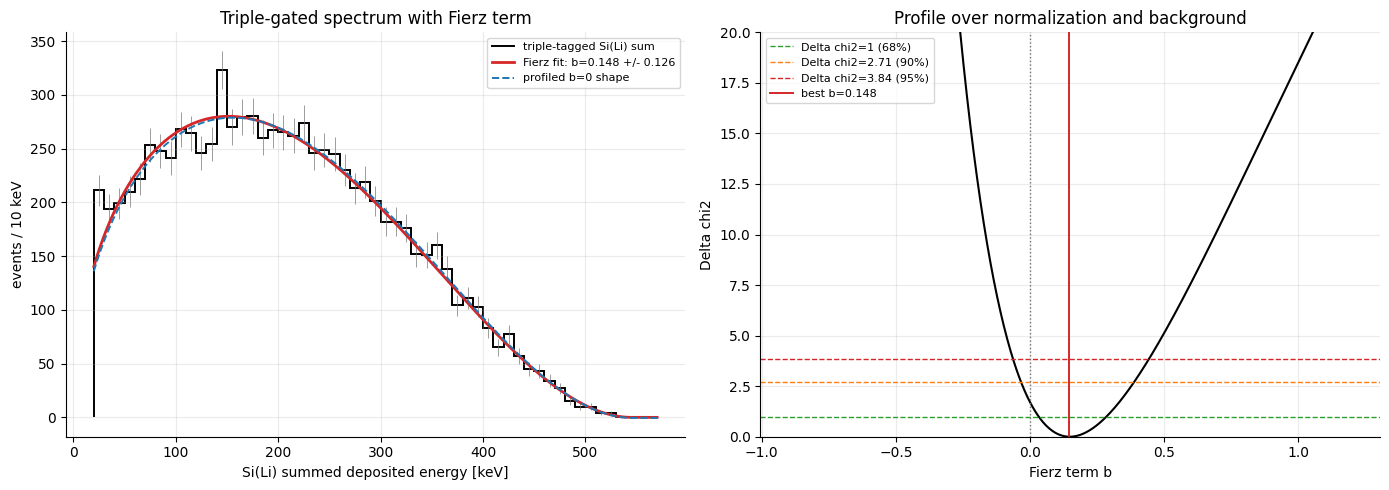

saved output/notebook_figures/sili_sum_triple_hpge_fierz_fit.png


,value
b_direct_fit,0.148272
b_direct_fit_err_covariance,0.125631
b_profile_best,0.147500
b_68_lower,0.032429
b_68_upper,0.285523
b_90_lower,-0.033294
b_90_upper,0.388603
b_95_lower,-0.062961
b_95_upper,0.443478
endpoint_fixed_keV,545.000000


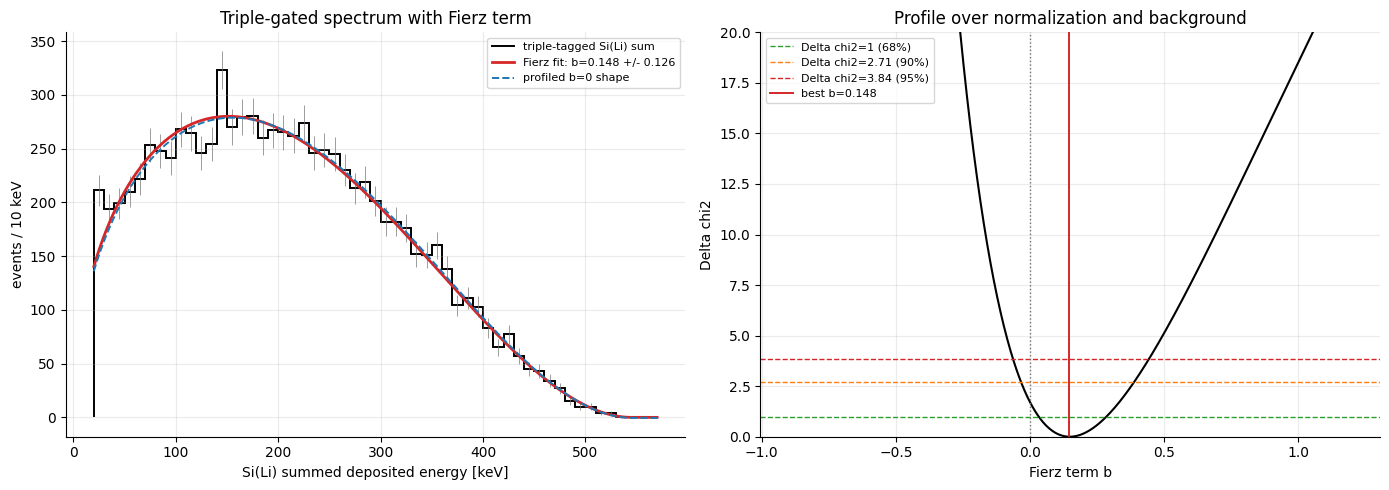

In [35]:
# Fierz-term fit and profile-likelihood-style bounds.
# The Fierz term modifies the allowed beta+ shape by (1 + b * m_e / E_total).
FIERZ_PROFILE_RANGE = (-0.90, 1.20)
FIERZ_PROFILE_POINTS = 841


def beta_plus_fierz_shape(kinetic_keV, endpoint_keV, fierz_b):
    kinetic_keV = np.asarray(kinetic_keV, dtype=float)
    shape = np.zeros_like(kinetic_keV, dtype=float)
    mask = (kinetic_keV > 0.0) & (kinetic_keV < endpoint_keV)
    if not np.any(mask):
        return shape
    k = kinetic_keV[mask]
    momentum_keV = np.sqrt(k * (k + 2.0 * ELECTRON_MASS_KEV))
    total_energy_keV = k + ELECTRON_MASS_KEV
    fierz_factor = 1.0 + fierz_b * ELECTRON_MASS_KEV / total_energy_keV
    shape[mask] = momentum_keV * total_energy_keV * (endpoint_keV - k) ** 2 * fierz_factor
    if np.any(shape[mask] < 0.0):
        return np.full_like(shape, np.nan)
    max_shape = np.nanmax(shape)
    return shape / max_shape if max_shape > 0 else shape


def beta_plus_fierz_model(kinetic_keV, norm, fierz_b, background):
    return norm * beta_plus_fierz_shape(
        kinetic_keV, BETA_PLUS_ENDPOINT_22NA_KEV, fierz_b
    ) + background


def fit_fierz_direct(centers, counts):
    mask = counts > 0
    x = centers[mask]
    y = counts[mask]
    sigma_y = np.sqrt(np.maximum(y, 1.0))
    p0 = [max(y.max(), 1.0), 0.0, 0.0]
    bounds = ([0.0, FIERZ_PROFILE_RANGE[0], -20.0], [np.inf, FIERZ_PROFILE_RANGE[1], np.inf])
    popt, pcov = curve_fit(
        beta_plus_fierz_model,
        x,
        y,
        p0=p0,
        sigma=sigma_y,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=50000,
    )
    residual = (y - beta_plus_fierz_model(x, *popt)) / sigma_y
    chi2 = float(np.sum(residual ** 2))
    return popt, pcov, chi2, len(y) - len(popt)


def profile_fierz_b(centers, counts, b_values):
    mask = counts > 0
    x = centers[mask]
    y = counts[mask]
    sigma_y = np.sqrt(np.maximum(y, 1.0))
    chi2_values = []
    nuisance_values = []

    for b_value in b_values:
        shape = beta_plus_fierz_shape(x, BETA_PLUS_ENDPOINT_22NA_KEV, b_value)
        if not np.all(np.isfinite(shape)):
            chi2_values.append(np.inf)
            nuisance_values.append((np.nan, np.nan))
            continue

        def fixed_b_model(energy, norm, background):
            return norm * beta_plus_fierz_shape(
                energy, BETA_PLUS_ENDPOINT_22NA_KEV, b_value
            ) + background

        try:
            popt, _ = curve_fit(
                fixed_b_model,
                x,
                y,
                p0=[max(y.max(), 1.0), 0.0],
                sigma=sigma_y,
                absolute_sigma=True,
                bounds=([0.0, -20.0], [np.inf, np.inf]),
                maxfev=20000,
            )
            residual = (y - fixed_b_model(x, *popt)) / sigma_y
            chi2_values.append(float(np.sum(residual ** 2)))
            nuisance_values.append(tuple(popt))
        except Exception:
            chi2_values.append(np.inf)
            nuisance_values.append((np.nan, np.nan))

    return np.asarray(chi2_values), np.asarray(nuisance_values)


def profile_interval(x, y, delta):
    finite = np.isfinite(y)
    x = np.asarray(x)[finite]
    y = np.asarray(y)[finite]
    if len(x) < 3:
        return (np.nan, np.nan)
    best_index = int(np.argmin(y))
    target = y[best_index] + delta

    lower = np.nan
    for i in range(best_index, 0, -1):
        if (y[i] - target) * (y[i - 1] - target) <= 0:
            lower = np.interp(target, [y[i], y[i - 1]], [x[i], x[i - 1]])
            break

    upper = np.nan
    for i in range(best_index, len(x) - 1):
        if (y[i] - target) * (y[i + 1] - target) <= 0:
            upper = np.interp(target, [y[i], y[i + 1]], [x[i], x[i + 1]])
            break

    return lower, upper


# Reuse the same binned triple-gated spectrum as the endpoint fit.
fierz_counts = triple_beta_fit["counts"]
fierz_centers = triple_beta_fit["centers"]
fierz_bins = triple_beta_fit["bins"]
fierz_popt, fierz_pcov, fierz_chi2, fierz_ndof = fit_fierz_direct(fierz_centers, fierz_counts)
fierz_perr = np.sqrt(np.diag(fierz_pcov))

b_grid = np.linspace(*FIERZ_PROFILE_RANGE, FIERZ_PROFILE_POINTS)
profile_chi2, profile_nuisance = profile_fierz_b(fierz_centers, fierz_counts, b_grid)
best_profile_index = int(np.nanargmin(profile_chi2))
b_best_profile = b_grid[best_profile_index]
chi2_min_profile = profile_chi2[best_profile_index]
profile_delta = profile_chi2 - chi2_min_profile

b_68 = profile_interval(b_grid, profile_chi2, 1.00)
b_90 = profile_interval(b_grid, profile_chi2, 2.71)
b_95 = profile_interval(b_grid, profile_chi2, 3.84)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].stairs(fierz_counts, fierz_bins, label="triple-tagged Si(Li) sum", linewidth=1.4, color="black")
axes[0].errorbar(
    fierz_centers,
    fierz_counts,
    yerr=np.sqrt(np.maximum(fierz_counts, 1.0)),
    fmt="none",
    ecolor="0.45",
    elinewidth=0.7,
    alpha=0.7,
)
xfit = np.linspace(fierz_bins[0], fierz_bins[-1], 700)
axes[0].plot(
    xfit,
    beta_plus_fierz_model(xfit, *fierz_popt),
    color="tab:red",
    linewidth=2.0,
    label=f"Fierz fit: b={fierz_popt[1]:.3f} +/- {fierz_perr[1]:.3f}",
)
b0_nuisance = profile_nuisance[np.argmin(np.abs(b_grid - 0.0))]
axes[0].plot(
    xfit,
    b0_nuisance[0] * beta_plus_fierz_shape(xfit, BETA_PLUS_ENDPOINT_22NA_KEV, 0.0) + b0_nuisance[1],
    color="tab:blue",
    linestyle="--",
    linewidth=1.4,
    label="profiled b=0 shape",
)
axes[0].set_xlabel("Si(Li) summed deposited energy [keV]")
axes[0].set_ylabel("events / 10 keV")
axes[0].set_title("Triple-gated spectrum with Fierz term")
axes[0].legend(fontsize=8)

axes[1].plot(b_grid, profile_delta, color="black", linewidth=1.5)
for delta, label, color in [(1.00, "68%", "tab:green"), (2.71, "90%", "tab:orange"), (3.84, "95%", "tab:red")]:
    axes[1].axhline(delta, color=color, linestyle="--", linewidth=1.0, label=f"Delta chi2={delta:g} ({label})")
axes[1].axvline(b_best_profile, color="tab:red", linewidth=1.4, label=f"best b={b_best_profile:.3f}")
axes[1].axvline(0.0, color="0.45", linestyle=":", linewidth=1.0)
axes[1].set_xlabel("Fierz term b")
axes[1].set_ylabel("Delta chi2")
axes[1].set_ylim(bottom=0.0, top=max(6.0, np.nanmin([np.nanmax(profile_delta), 20.0])))
axes[1].set_title("Profile over normalization and background")
axes[1].legend(fontsize=8)
savefig(fig, "sili_sum_triple_hpge_fierz_fit.png")

fierz_summary = pd.Series({
    "b_direct_fit": fierz_popt[1],
    "b_direct_fit_err_covariance": fierz_perr[1],
    "b_profile_best": b_best_profile,
    "b_68_lower": b_68[0],
    "b_68_upper": b_68[1],
    "b_90_lower": b_90[0],
    "b_90_upper": b_90[1],
    "b_95_lower": b_95[0],
    "b_95_upper": b_95[1],
    "endpoint_fixed_keV": BETA_PLUS_ENDPOINT_22NA_KEV,
    "chi2_ndof_direct_fit": fierz_chi2 / fierz_ndof,
    "chi2_ndof_profile_best": chi2_min_profile / (np.count_nonzero(fierz_counts > 0) - 2),
})
display(fierz_summary.to_frame("value"))

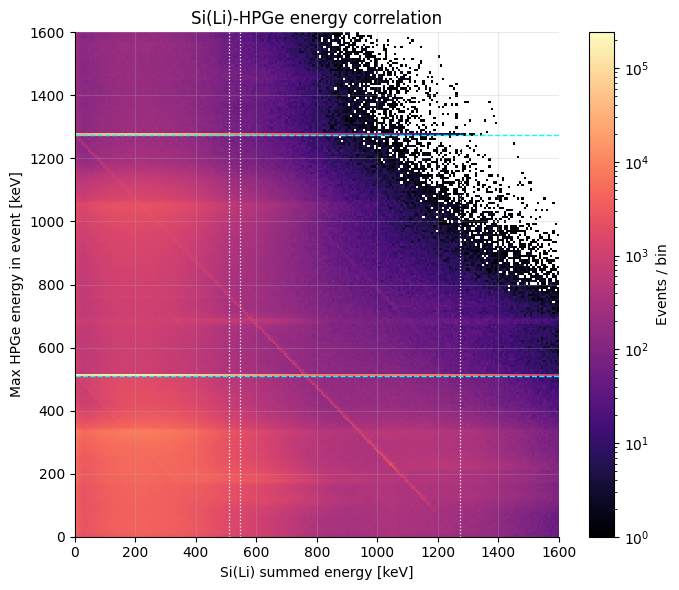

saved output/notebook_figures/sili_hpge_correlation.png


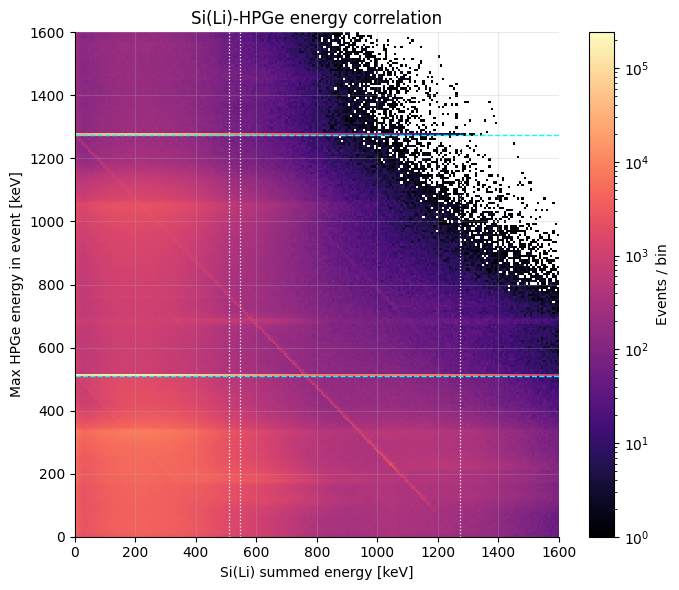

In [34]:
from matplotlib.colors import LogNorm

mask = (
    np.isfinite(silisum)
    & np.isfinite(hpge_max)
    & (silisum > 0.1)
    & (hpge_max > 0.1)
)

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(
    silisum[mask],
    hpge_max[mask],
    bins=[220, 220],
    range=[[0, 1600], [0, 1600]],
    cmap="magma",
    norm=LogNorm(),
    cmin=1,
)
fig.colorbar(h[3], ax=ax, label="Events / bin")

for energy in [EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axhline(energy, color="cyan", linestyle="--", linewidth=1)

for energy in [545, EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axvline(energy, color="white", linestyle=":", linewidth=0.9)

ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel("Max HPGe energy in event [keV]")
ax.set_title("Si(Li)-HPGe energy correlation")
savefig(fig, "sili_hpge_correlation.png")

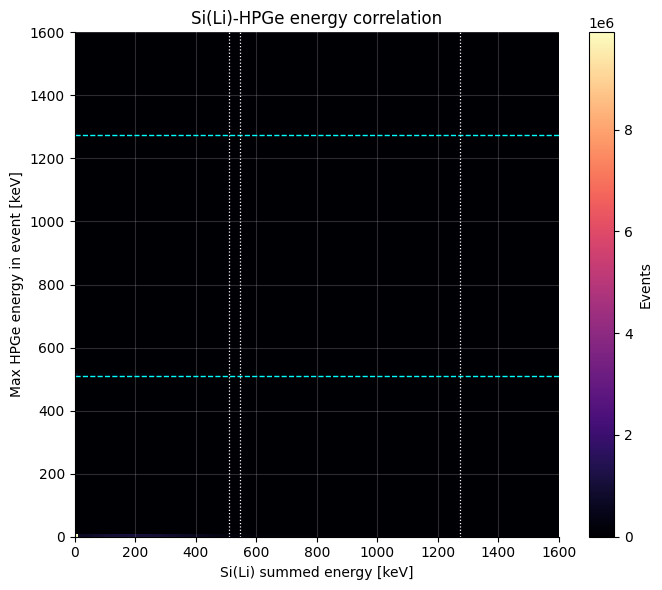

saved output/notebook_figures/sili_hpge_correlation.png


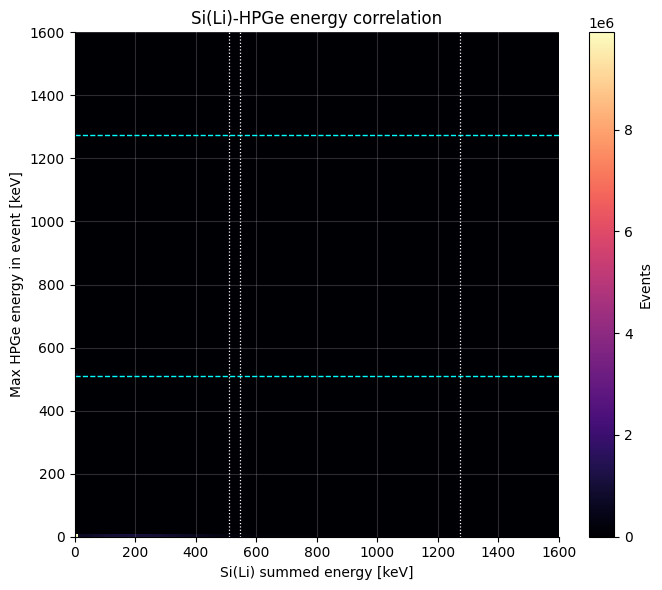

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(silisum, hpge_max, bins=[160, 160], range=[[0, 1600], [0, 1600]], cmap="magma")
fig.colorbar(h[3], ax=ax, label="Events")
for energy in [EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axhline(energy, color="cyan", linestyle="--", linewidth=1)
for energy in [545, EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axvline(energy, color="white", linestyle=":", linewidth=0.9)
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel("Max HPGe energy in event [keV]")
ax.set_title("Si(Li)-HPGe energy correlation")
savefig(fig, "sili_hpge_correlation.png")

## Fit Summary

The tables below collect successful peak and edge fits for quick inspection.

In [23]:
peak_summary = fit_table[fit_table["ok"] == True].copy()
edge_summary = edge_table[edge_table["ok"] == True].copy()
cols_peak = ["label", "expected_keV", "mu_keV", "mu_err_keV", "sigma_keV", "fwhm_keV", "area_counts"]
cols_edge = ["label", "expected_keV", "edge_keV", "edge_err_keV", "sigma_keV"]
print("Successful peak fits")
display(peak_summary[[c for c in cols_peak if c in peak_summary.columns]])
print("Successful Compton edge fits")
display(edge_summary[[c for c in cols_edge if c in edge_summary.columns]])

Successful peak fits


,label,expected_keV,mu_keV,mu_err_keV,sigma_keV,fwhm_keV,area_counts
0,HPGe_all 511,511.0,510.514221,0.001324,0.259197,0.610363,5.334334e+06
1,HPGe_all 1274.5,1274.5,1274.003155,0.005632,0.235427,0.554389,1.476119e+06
2,HPGe_1_keV 511,511.0,510.497204,0.002139,0.258809,0.609448,1.779689e+06
3,HPGe_1_keV 1274.5,1274.5,1274.000388,0.009588,0.235756,0.555164,4.875998e+05
4,HPGe_2_keV 511,511.0,510.497270,0.002142,0.258748,0.609305,1.777857e+06
5,HPGe_2_keV 1274.5,1274.5,1274.005798,0.009410,0.236165,0.556126,4.907089e+05
6,HPGe_3_keV 511,511.0,510.496336,0.002072,0.259159,0.610273,1.806037e+06
7,HPGe_3_keV 1274.5,1274.5,1274.002207,0.009939,0.235308,0.554108,4.854149e+05


Successful Compton edge fits


,label,expected_keV,edge_keV,edge_err_keV,sigma_keV
0,511 keV Compton edge,340.666667,355.069118,0.038608,24.657964
1,1274.5 keV Compton edge,1061.666830,1096.363573,0.119476,59.499832


## Notes And Next Steps

- The HPGe peak centroids should sit close to 511 and 1274.5 keV in this unsmeared simulation.
- Si(Li) symmetry should improve with larger event counts.
- The Si(Li) summed spectrum is the key spectrum for backscatter recovery studies.
- Future refinements: add detector resolution smearing, use larger statistics for edge fits, and add truth-level columns by running with `/output/truthOutput true`.